In [ ]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import pymysql
warnings.filterwarnings("ignore")


# **Connect to database**

In [13]:
conn = pymysql.connect(
    host="localhost",
    database="ia",
    user="root",
    password="Globallogic2026@",
    port=3306
)

print("Conectado")

Conectado


In [15]:
cursor = conn.cursor()

cursor.execute("SELECT * FROM partidos LIMIT 10;")

print(cursor.fetchone())

(1930, '13 Jul 1930 - 15:00 ', 'Group 1', 'Pocitos', 'Montevideo ', 'France', 4, 1, 'Mexico', ' ', 4444.0, 3, 0, 'LOMBARDI Domingo (URU)', 'CRISTOPHE Henry (BEL)', 'REGO Gilberto (BRA)', 201, 1096, 'FRA', 'MEX')


# **Queries** 

In [16]:
query = """
SELECT *
FROM partidos
LIMIT 10
"""

df = pd.read_sql(query, conn)

df

,Year,Datetime,Stage,Stadium,City,HomeTeamName,HomeTeamGoals,AwayTeamGoals,AwayTeamName,WinConditions,Attendance,HalfTimeHomeGoals,HalfTimeAwayGoals,Referee,Assistant1,Assistant2,RoundID,MatchID,HomeTeamInitials,AwayTeamInitials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA
5,1930,16 Jul 1930 - 14:45,Group 1,Parque Central,Montevideo,Chile,3,0,Mexico,,9249.0,1,0,CRISTOPHE Henry (BEL),APHESTEGUY Martin (URU),LANGENUS Jean (BEL),201,1095,CHI,MEX
6,1930,17 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,4,0,Bolivia,,18306.0,0,0,MATEUCCI Francisco (URU),LOMBARDI Domingo (URU),WARNKEN Alberto (CHI),201,1092,YUG,BOL
7,1930,17 Jul 1930 - 14:45,Group 4,Parque Central,Montevideo,USA,3,0,Paraguay,,18306.0,2,0,MACIAS Jose (ARG),APHESTEGUY Martin (URU),TEJADA Anibal (URU),201,1097,USA,PAR
8,1930,18 Jul 1930 - 14:30,Group 3,Estadio Centenario,Montevideo,Uruguay,1,0,Peru,,57735.0,0,0,LANGENUS Jean (BEL),BALWAY Thomas (FRA),CRISTOPHE Henry (BEL),201,1099,URU,PER
9,1930,19 Jul 1930 - 12:50,Group 1,Estadio Centenario,Montevideo,Chile,1,0,France,,2000.0,0,0,TEJADA Anibal (URU),LOMBARDI Domingo (URU),REGO Gilberto (BRA),201,1094,CHI,FRA


In [17]:
def get_matches_by_year(year):

    query = """
    SELECT *
    FROM partidos
    WHERE year = %s
    """

    return pd.read_sql(
        query,
        conn,
        params=(str(year),)
    )

In [18]:
get_matches_by_year(1930)

,Year,Datetime,Stage,Stadium,City,HomeTeamName,HomeTeamGoals,AwayTeamGoals,AwayTeamName,WinConditions,Attendance,HalfTimeHomeGoals,HalfTimeAwayGoals,Referee,Assistant1,Assistant2,RoundID,MatchID,HomeTeamInitials,AwayTeamInitials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA
5,1930,16 Jul 1930 - 14:45,Group 1,Parque Central,Montevideo,Chile,3,0,Mexico,,9249.0,1,0,CRISTOPHE Henry (BEL),APHESTEGUY Martin (URU),LANGENUS Jean (BEL),201,1095,CHI,MEX
6,1930,17 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,4,0,Bolivia,,18306.0,0,0,MATEUCCI Francisco (URU),LOMBARDI Domingo (URU),WARNKEN Alberto (CHI),201,1092,YUG,BOL
7,1930,17 Jul 1930 - 14:45,Group 4,Parque Central,Montevideo,USA,3,0,Paraguay,,18306.0,2,0,MACIAS Jose (ARG),APHESTEGUY Martin (URU),TEJADA Anibal (URU),201,1097,USA,PAR
8,1930,18 Jul 1930 - 14:30,Group 3,Estadio Centenario,Montevideo,Uruguay,1,0,Peru,,57735.0,0,0,LANGENUS Jean (BEL),BALWAY Thomas (FRA),CRISTOPHE Henry (BEL),201,1099,URU,PER
9,1930,19 Jul 1930 - 12:50,Group 1,Estadio Centenario,Montevideo,Chile,1,0,France,,2000.0,0,0,TEJADA Anibal (URU),LOMBARDI Domingo (URU),REGO Gilberto (BRA),201,1094,CHI,FRA


In [19]:
query = """
SELECT
    year,
    COUNT(*) AS matches
FROM partidos
GROUP BY year
ORDER BY year
"""

df = pd.read_sql(query, conn)

df

,year,matches
0,1930,18
1,1934,17
2,1938,18
3,1950,22
4,1954,26
5,1958,35
6,1962,32
7,1966,32
8,1970,32
9,1974,38


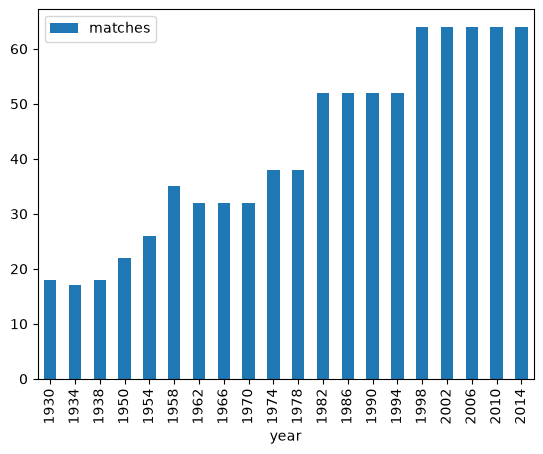

In [20]:
df.plot(
    x="year",
    y="matches",
    kind="bar"
)

plt.show()

# **PROOF API**

In [23]:
import requests

BASE_URL = "http://127.0.0.1:8000"

# 1) Verificar que la API este activa
health_response = requests.get(f"{BASE_URL}/health", timeout=10)
print("/health ->", health_response.status_code, health_response.json())

# 2) Probar consulta de partidos
matches_response = requests.get(
    f"{BASE_URL}/matches",
    params={"limit": 5, "offset": 0},
    timeout=10,
)
print("/matches ->", matches_response.status_code)

if matches_response.ok:
    data = matches_response.json()
    print("Registros recibidos:", len(data))
    if data:
        print("Primer registro:")
        print(data[0])
else:
    print(matches_response.text)

/health -> 200 {'status': 'ok'}
/matches -> 200
Registros recibidos: 5
Primer registro:
{'Year': 1930, 'Datetime': '13 Jul 1930 - 15:00 ', 'Stage': 'Group 1', 'Stadium': 'Pocitos', 'City': 'Montevideo ', 'HomeTeamName': 'France', 'HomeTeamGoals': 4, 'AwayTeamGoals': 1, 'AwayTeamName': 'Mexico', 'WinConditions': ' ', 'Attendance': 4444.0, 'HalfTimeHomeGoals': 3, 'HalfTimeAwayGoals': 0, 'Referee': 'LOMBARDI Domingo (URU)', 'Assistant1': 'CRISTOPHE Henry (BEL)', 'Assistant2': 'REGO Gilberto (BRA)', 'RoundID': 201, 'MatchID': 1096, 'HomeTeamInitials': 'FRA', 'AwayTeamInitials': 'MEX'}
